In [1]:
# %load_ext autoreload
# %autoreload 2

import torch
from torch import nn
from torch.utils.data import random_split, DataLoader, Subset
from torchvision import datasets
from torchvision.transforms import ToTensor

import os
import pandas as pd
from torch.utils.data import Dataset
# import sklearn
from sklearn.model_selection import train_test_split
from torchvision.transforms import ToTensor, Lambda
import matplotlib.colors as mcolors

from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
import sys
sys.path.insert(0, '../')
from utils import *
import matplotlib.pyplot as plt
import wandb
import datetime

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sn
import numpy as np
import matplotlib.colors as mcolors
from matplotlib import rc
plt.rc("text", usetex=True)  # Enable LaTeX
os.environ["PATH"] += os.pathsep + "/software/texlive/2015/bin/x86_64-linux/"
from matplotlib.lines import Line2D

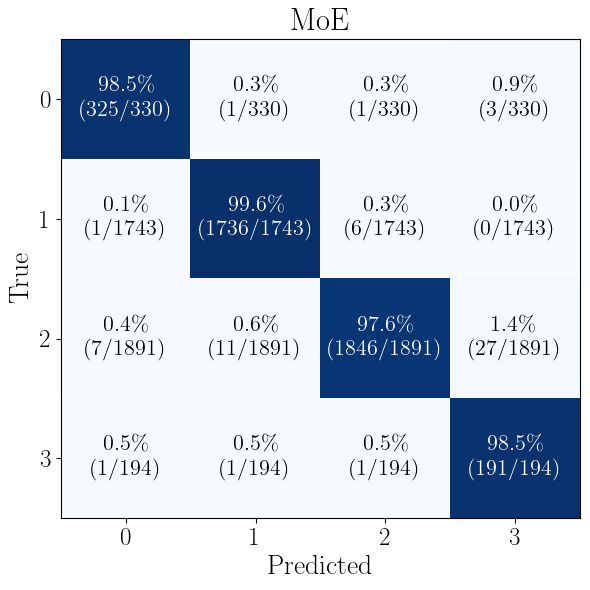

In [4]:
#-- Load the data 
data = np.load('../data_splits_splot22f_1215.npz')
y_test = data['y_test'][:,0].flatten().astype(int)


# Create panel with all three
fig, axes = plt.subplots(1, 1, figsize=(6, 6))

# -- Load the NN model 
NN_results = np.load('results/class_results.npz', allow_pickle=True)
y_pred_NN = NN_results['y_pred_test']
gen_confusion_matrix(y_test, y_pred_NN, r'$\rm MoE$', ax=axes)

plt.tight_layout()
fig.savefig('../figures/MoE_confusion_matrices_panel.pdf', dpi=300, bbox_inches='tight')
plt.show()

**Decision Boundaries**

In [5]:
def load_and_plot_SVC(ax, feature_idx, fixed_values={}, labels=[], method = 'MoE', legends = [True, True]):

    import joblib
    sys.path.insert(0, './NN/')

    import os
    from MOE import TaskSpecificMoE
    print(os.getcwd())
    
    # --- Load saved model, scaler, and results ---

    data = np.load('../data_splits_splot22f_1215.npz')
    X_train = data['X_train']
    y_train = data['y_train'][:, :1].flatten().astype(int)
    X_val = data['X_val']
    y_val = data['y_val'][:, :1].flatten().astype(int)
    X_test = data['X_test']
    y_test = data['y_test'][:, :1].flatten().astype(int)

    model_name = './best_models/MoE_best_model.pt'
    model = TaskSpecificMoE()
    checkpoint = torch.load(model_name, map_location=torch.device('cpu'), weights_only = False)
    model.load_state_dict(checkpoint["model_state_dict"])
    scaler = [checkpoint["train_mean"], checkpoint["train_std"]]
    

    # --- Generate the plot ---

    ax = N_gridsearch_plotter(ax, X_train, y_train, X_test, y_test, X_val, y_val,
                             model=model,
                             scaler=scaler,
                             feature_idx=feature_idx,
                             fixed_values=fixed_values,
                             labels=labels,
                             method = method,
                             legends = legends,
                             )

    return ax


def get_stellar_radius(age, mass, filename='/projects/b1091/SPH_ML_grid/starsmasher/0.01Zsun/relaxations/stellar_radii.csv'):
    # Load CSV
    df = pd.read_csv(filename)

    # --- Step 1: find the closest age ---
    df['age_diff'] = np.abs(df['1:Time[Gyr]'] - age)
    min_age_diff = df['age_diff'].min()

    # all rows with the closest age (could be multiple mass entries)
    age_matches = df[df['age_diff'] == min_age_diff]

    # --- Step 2: among those, find the closest mass ---
    age_matches['mass_diff'] = np.abs(age_matches['0:Mass[Msun]'] - mass)
    best_row = age_matches.loc[age_matches['mass_diff'].idxmin()]

    if len(best_row) == 0:
        print("No match found for age={} and mass={}".format(age, mass))
        return None
    else:
        # Return the radius (assume only one match)
        print(f"Age {age} matched with {best_row['1:Time[Gyr]']}")
        return best_row['2:Radius[Rsun]']


def N_gridsearch_plotter(ax, X_train, y_train, X_test, y_test, X_val, y_val, model, scaler, feature_idx, fixed_values={}, labels = [], method = 'kNN', num_classes = 4, legends = [True, True]):
    """
    Plots the decision boundary for a PyTorch model using a 2D slice of a higher-dimensional space.
    
    Parameters:
    - X_train, X_test, X_val: float arrays, containing (unnormalized) data for training, testing, and validation sets 
    - y_train, y_test, y_val: float arrays, containing (unnormalized) labels for training, testing, and validation sets 
    - model: Trained model.
    - scaler: to be used to transfor the data into the format taken by the model
    - feature_idx: Tuple (i, j) specifying which two features to plot.
    - fixed_values: Dictionary {feature_index: value} for fixing other dimensions. Unnormalized (same format as train/test/val tests)
    - labels:  list of strings 
    - method: method to evaluate
    """

    # Step 1: Filter train and test data based on fixed_values

    train_mask = np.logical_and.reduce([np.isclose(X_train[:, k], v, rtol=0.01) for k, v in fixed_values.items()])
    val_mask = np.logical_and.reduce([np.isclose(X_val[:, k], v, rtol=0.01) for k, v in fixed_values.items()])
    test_mask = np.logical_and.reduce([np.isclose(X_test[:, k], v, rtol=0.01) for k, v in fixed_values.items()])
    
    if (train_mask.sum() == 0 and test_mask.sum() == 0 and val_mask.sum() == 0):
        print("No data points!")
        return None

    X_train_filtered, y_train_filtered = X_train[train_mask], y_train[train_mask]
    X_val_filtered, y_val_filtered = X_val[val_mask], y_val[val_mask]
    X_test_filtered, y_test_filtered = X_test[test_mask], y_test[test_mask]
    
    # Step 2: Create a meshgrid for the chosen two features
    
    x_min, x_max = X_train_filtered[:, feature_idx[0]].min() - 0.1, X_train_filtered[:, feature_idx[0]].max() + 0.1
    y_min, y_max = X_train_filtered[:, feature_idx[1]].min() - 0.1, X_train_filtered[:, feature_idx[1]].max() + 0.1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))

    # Step 4: Standard normalize the data like you did before
    fixed_values_norm = {}
        
   
    train_mean = scaler[0]
    train_std = scaler[1]
    xx_norm = (xx - train_mean[feature_idx[0]]) / train_std[feature_idx[0]]
    yy_norm = (yy - train_mean[feature_idx[1]]) / train_std[feature_idx[1]]

    # Scale the fixed values according to the method
    for k, v in fixed_values.items():
        fixed_values_norm[k] = (v - train_mean[k]) / train_std[k]

    # Step 3: Construct full-dimensional input space for predictions
    X_vis = torch.zeros((xx_norm.ravel().shape[0], X_train.shape[1]), dtype=torch.float32)
    X_vis[:, feature_idx[0]] = torch.tensor(xx_norm.ravel(), dtype=torch.float32)
    X_vis[:, feature_idx[1]] = torch.tensor(yy_norm.ravel(), dtype=torch.float32)

    # Assign fixed values to other dimensions
    for k, v in fixed_values_norm.items():
        X_vis[:, k] = v

    # Step 4: Predict labels for meshgrid

    model.eval()
    with torch.no_grad():
        Z, _ = model(X_vis)
        Z = Z.argmax(dim=1).numpy()

    Z = Z.reshape(xx.shape)

    # Normalize color mapping to match the scatter points and contour
    cmap = plt.cm.coolwarm  # Set the same colormap
    norm = mcolors.Normalize(vmin=0, vmax=2)  # Normalize colors

    if num_classes > 3: 

        # Define your own hex colors for each label
        hex_colors = ['lightgrey', '#386FA4', '#678D58', '#8E3B46'] # grey, blue, green, red

        # Create a discrete colormap from your chosen colors
        cmap = mcolors.ListedColormap(hex_colors)

        # Define the normalization so labels 0–3 map to your colors
        norm = mcolors.BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5], ncolors=len(hex_colors))


    #Get stellar radius in Rsun
    rad1 = get_stellar_radius(round(float(labels[4]),5), float(labels[2]))
    rad2 = get_stellar_radius(round(float(labels[4]),5), float(labels[3]))
    print(rad1, rad2)
    # Step 5: Plot decision boundary
    # ax.contourf((10**xx-0.1)/(rad1 + rad2), np.log10(10**yy - 10), Z, alpha=0.5, cmap=cmap, norm=norm)
  
    # ax.scatter((10**X_train_filtered[:, feature_idx[0]] -0.1) / (rad1 + rad2), np.log10(10**X_train_filtered[:, feature_idx[1]] - 10), c=y_train_filtered, cmap=cmap, norm = norm, edgecolor="k", marker='o')
    # ax.scatter((10**X_val_filtered[:, feature_idx[0]] -0.1)   / (rad1 + rad2), np.log10(10**X_val_filtered[:, feature_idx[1]]- 10), c=y_val_filtered, cmap=cmap, norm = norm, edgecolor="k", marker='s')
    # ax.scatter((10**X_test_filtered[:, feature_idx[0]]-0.1)   /(rad1 + rad2), np.log10(10**X_test_filtered[:, feature_idx[1]]- 10), c=y_test_filtered, cmap=cmap, norm = norm, edgecolor="k", marker='^' )
    
    ax.contourf((10**xx-0.1), np.log10(10**yy - 10), Z, alpha=0.5, cmap=cmap, norm=norm)
  
    ax.scatter((10**X_train_filtered[:, feature_idx[0]] -0.1) , np.log10(10**X_train_filtered[:, feature_idx[1]] - 10), c=y_train_filtered, cmap=cmap, norm = norm, edgecolor="k", marker='o')
    ax.scatter((10**X_val_filtered[:, feature_idx[0]] -0.1)   , np.log10(10**X_val_filtered[:, feature_idx[1]]- 10), c=y_val_filtered, cmap=cmap, norm = norm, edgecolor="k", marker='s')
    ax.scatter((10**X_test_filtered[:, feature_idx[0]]-0.1)   , np.log10(10**X_test_filtered[:, feature_idx[1]]- 10), c=y_test_filtered, cmap=cmap, norm = norm, edgecolor="k", marker='^' )
    

    ax.set_xlabel(fr" {labels[0]}", fontsize = 15)
    ax.set_ylabel(fr" {labels[1]}", fontsize = 15)
    ax.tick_params(axis='both', which='major', labelsize=13)  # or any size you prefer
    # ax.set_title(fr"$\mathrm{{T}} = {round((float(labels[4])),3)}\ \mathrm{{Gyr}}, \, \mathrm{{M_1}} = {labels[2]}\ M_\odot,\ \mathrm{{M_2}} = {labels[3]}\ M_\odot $", fontsize = 20)
    ax.set_title(fr"$\mathrm{{T}} = {round((float(labels[4])),5)}\ \mathrm{{Gyr}}, \, \mathrm{{M_1}} = {labels[2]}\ M_\odot,\ \mathrm{{M_2}} = {labels[3]}\ M_\odot $", fontsize = 20)

    # --- X axis log scale and custom ticks ---
    # ax.set_xscale('log') 

    # --- Y axis custom ticks ---
    ax.set_yticks([1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0])    
    ax.set_yticklabels([r'$1.0$', r'$1.5$', r'$2.0$', r'$2.5$', r'$3.0$', r'$3.5$', r'$4.0$'])   

    # --- Small ticks inside the plot ---
    ax.minorticks_on()
    ax.tick_params(axis='both', which='major', direction='in', length=6, labelsize=13)
    ax.tick_params(axis='both', which='minor', direction='in', length=3)  # smaller minor ticks

    if legends[0]:
        legend_elements = [
        Line2D([0], [0], marker='o', color='k', label=r'$\rm Train$', linestyle='None', markersize=5),
        Line2D([0], [0], marker='s', color='k', label=r'$\rm Val$',   linestyle='None', markersize=5),
        Line2D([0], [0], marker='^', color='k', label=r'$\rm Test$',  linestyle='None', markersize=5),]

        ax.legend(handles=legend_elements, fontsize=15)#20
    if legends[1]:
        legend_elements = [
        Line2D([0], [0], marker='o', color='lightgrey', label=r'$0$', linestyle='None', markersize=5),
        Line2D([0], [0], marker='o', color='#386FA4', label=r'$1$',   linestyle='None', markersize=5),
        Line2D([0], [0], marker='o', color='#678D58', label=r'$2$',  linestyle='None', markersize=5),
        Line2D([0], [0], marker='o', color='#8E3B46', label=r'$3$',  linestyle='None', markersize=5),]

        ax.legend(handles=legend_elements, title = r"$ \rm Class $", title_fontsize = 16, fontsize=15, loc = 'lower left') 


    # plt.tight_layout()
    return ax
    

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

data = np.load('../data_splits_splot22f_1215.npz')
X_train = data['X_train']
y_train = data['y_train'][:, :1].flatten().astype(int)
X_val = data['X_val']
y_val = data['y_val'][:, :1].flatten().astype(int)
X_test = data['X_test']
y_test = data['y_test'][:, :1].flatten().astype(int)

unique_pairs = np.unique(X_train[:, [0, 3, 4]], axis=0)


with PdfPages('MoE_boundary_plots_3.pdf') as pdf:

    for unique in unique_pairs:

        # Create figure and axes grid with only shared y-axis
        fig, axes = plt.subplots(1, 1, 
                                figsize=(6*1, 5*1), 
                                sharey=True)

        # Ensure axes is 2D array

        axes = np.expand_dims(axes, 0)
        axes = np.expand_dims(axes, 1)

        # Remove whitespace between subplots
        plt.subplots_adjust(hspace=0, wspace=0)

        # Define which panels get legends (row, col)
        legend_panels = {
            (0, 0): [True, False],   # Top-left: data split legend
            (0, 1): [False, True],   # Top-right: class legend
        }

        print('*'*60)
        ax = axes[0, 0]
        time, mass1, mass2 = unique[0], unique[1], unique[2]
                
        labels = [r'$\rm r_p / (R_1 + R_2)$', r'$\rm log_{10}(v_{\infty} \, [km/s])$', 
                str(round(np.exp(mass1),0)), str(round(np.exp(mass2),0)), 
                str(10**(time) - 0.001)]
        
        # Check if this panel should have legends
        legends = legend_panels.get((0, 0), [False, False])

        load_and_plot_SVC(ax, feature_idx=(1,2),
                         fixed_values={0: time, 3: mass1, 4: mass2},
                         labels=labels,
                         method='MoE',
                         legends=legends)

        if fig != None:
            # Save the current figure to the PDF
            pdf.savefig(fig, bbox_inches='tight')
            plt.show()
            plt.close(fig)
        else:
            print("Nothing returned")



# Violin Plot Comparison #

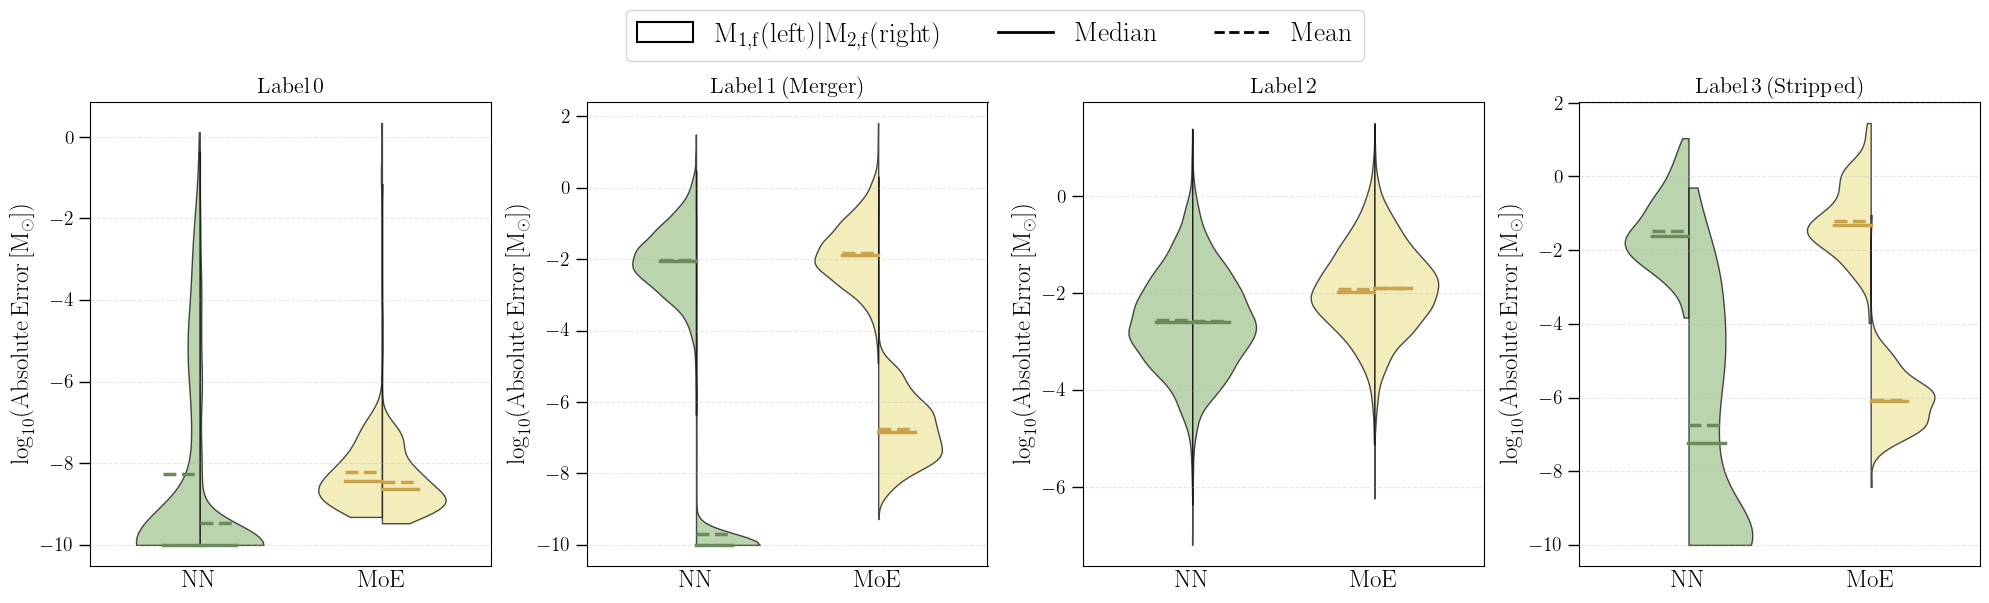

In [10]:
def violin_plots_classes():
    import numpy as np
    import matplotlib.pyplot as plt
    import sys
    sys.path.insert(0, './NN/')
    import os
    
    # --- Load saved results ---
    method_names = ['NN', 'MoE']
    colors = ['#9DC38B', '#EFE6A0']  # Blue for NN, Pink for MoE
    median_colors = ['#6B8C5A', '#C9A44C']
    
    data = np.load('../data_splits_splot22f_1215.npz')
    y_test = data['y_test'][:, :1].flatten().astype(int)


    # Load all data first
    all_methods_data = []
    for method in method_names:
        if method == 'NN':
            # data_class = np.load('../classification/results/NN_results.npz', allow_pickle=True)
            data_reg = np.load('../regression/results/NN_results.npz', allow_pickle=True)
            # class_labels = data_class['y_true_test']
            pred_mass1_test, pred_mass2_test = data_reg["y_pred_test"] 
            true_mass1_test, true_mass2_test = data_reg["y_true_test"] 

        else:
            # data_class = np.load('./results/class_results.npz', allow_pickle=True)
            data_reg = np.load('./results/reg_results.npz', allow_pickle=True)

            # class_labels = data_class['y_true_test']
            pred_mass1_test, pred_mass2_test = data_reg["y_pred_test"] 
            true_mass1_test, true_mass2_test = data_reg["y_true_test"] 

        all_methods_data.append({
            'class': y_test, 
            'pred_m1': pred_mass1_test,
            'pred_m2': pred_mass2_test,
            'true_m1': true_mass1_test,
            'true_m2': true_mass2_test
        })
    
    # Define the four plots (one per classification label)
    plot_configs = [
        {'title': r'$\rm{Label} \, 0$', 'ylabel': r'$\log_{10}(\rm Absolute \, Error \, [M_\odot])$', 'label': 0},
        {'title': r'$\rm{Label} \, 1 \, \rm{(Merger)}$', 'ylabel': r'$\log_{10}(\rm Absolute \, Error \, [M_\odot])$', 'label': 1},
        {'title': r'$\rm{Label} \, 2$', 'ylabel': r'$\log_{10}(\rm Absolute \, Error \, [M_\odot])$', 'label': 2},
        {'title': r'$\rm{Label} \, 3 \, \rm{(Stripped)}$', 'ylabel': r'$\log_{10}(\rm Absolute \, Error \, [M_\odot])$', 'label': 3}
    ]
    
    # Create subplots - 1 row, 4 columns
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    
    # Create each subplot
    for ax_idx, (ax, config) in enumerate(zip(axes, plot_configs)):
        
        # For each method (NN and MoE)
        for method_idx, (method_name, method_data) in enumerate(zip(method_names, all_methods_data)):
            
            # Filter data for this classification label
            idx = np.argwhere(method_data['class'] == config['label']).flatten()
            
            if len(idx) == 0:
                continue
                
            pred_m1 = method_data['pred_m1'][idx]
            true_m1 = method_data['true_m1'][idx]
            pred_m2 = method_data['pred_m2'][idx]
            true_m2 = method_data['true_m2'][idx]
            
            # Calculate errors (log scale)
            error_m1 = np.log10(np.abs(pred_m1 - true_m1) + 1e-10)
            error_m2 = np.log10(np.abs(pred_m2 - true_m2) + 1e-10)
            
            # Position for this method (NN at 1, MoE at 2)
            position = method_idx + 1
            
            # Plot M1 errors on left side
            parts_m1 = ax.violinplot(error_m1, positions=[position], 
                                       showmeans=False, showmedians=False, 
                                       widths=0.7, side='low', showextrema=False)
            
            # Color the violin
            for pc in parts_m1['bodies']:
                pc.set_facecolor(colors[method_idx])
                pc.set_alpha(0.7)
                pc.set_edgecolor('black')
                pc.set_linewidth(1)
            
            # Plot M2 errors on right side
            parts_m2 = ax.violinplot(error_m2, positions=[position], 
                                       showmeans=False, showmedians=False, 
                                       widths=0.7, side='high', showextrema=False)
            
            # Color the violin
            for pc in parts_m2['bodies']:
                pc.set_facecolor(colors[method_idx])
                pc.set_alpha(0.7)
                pc.set_edgecolor('black')
                pc.set_linewidth(1)
            
            # Calculate and plot median lines
            median_m1 = np.median(error_m1)
            median_m2 = np.median(error_m2)
            mean_m1 = np.mean(error_m1)
            mean_m2 = np.mean(error_m2)
            
            median_width = 0.2
            
            # Median for M1 (left side)
            ax.plot([position - median_width, position], [median_m1, median_m1],
                   color=median_colors[method_idx], linewidth=2.5, zorder=3, linestyle='-')
            # Median for M2 (right side)
            ax.plot([position, position + median_width], [median_m2, median_m2],
                   color=median_colors[method_idx], linewidth=2.5, zorder=3, linestyle='-')
            
            # Mean for M1 (left side)
            ax.plot([position - median_width, position], [mean_m1, mean_m1],
                   color=median_colors[method_idx], linewidth=2.5, zorder=3, linestyle='--')
            # Mean for M2 (right side)
            ax.plot([position, position + median_width], [mean_m2, mean_m2],
                   color=median_colors[method_idx], linewidth=2.5, zorder=3, linestyle='--')
        
        # Customize subplot
        ax.set_xticks([1, 2])
        ax.set_xticklabels([r'$\rm NN$', r'$ \rm MoE$'], fontsize=18)
        ax.set_ylabel(config['ylabel'], fontsize=18)
        ax.set_title(config['title'], fontsize=16, fontweight='bold')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_xlim(0.4, 2.6)
        ax.tick_params(axis='y', which='major', length=8, width=1, labelsize=14)
        ax.tick_params(axis='x', which='major', length=0, width=0)
    
    # Create custom legend
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='white', edgecolor='black', linewidth=1.5, label=r'$\rm M_{1,f} (left) | M_{2,f} (right)$'),
        Line2D([0], [0], color='black', linewidth=2, label=r'$ \rm Median$', linestyle='-'),
        Line2D([0], [0], color='black', linewidth=2, label=r'$ \rm Mean$', linestyle='--')
    ]
    fig.legend(handles=legend_elements, fontsize=20, loc='upper center', 
               bbox_to_anchor=(0.5, 1.05), ncol=3, frameon=True)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.94])
    
    plt.savefig('../figures/violin_moe_comparison.pdf', dpi=300, bbox_inches='tight')
    plt.show()

# Run the function
violin_plots_classes()

In [13]:
def moving_avg(data, size):
    
    '''Function to calculate the moving average of a data set. 
    
    PARAMETERS 
    ---------------------
    data: list, the data
    size: int, size of moving average window
    
    RETURN 
    ---------------------
    data: list, avegared data 
    '''

    import numpy as np

    data = np.asarray(data, dtype=float)

    avg_data = np.cumsum(data, dtype=float)
    avg_data[size:] = avg_data[size:] - avg_data[:-size]
    smoothed = avg_data[size - 1:] / size

    #add in the first point for visualization purposes 
    first_element = np.array([data[0]])
    # print(np.shape(first_element), np.shape(smoothed))
    final_array = np.concatenate([first_element,smoothed])
    # print(np.shape(final_array))

    return final_array


107
0.3605430424213409 0.2562520802021026


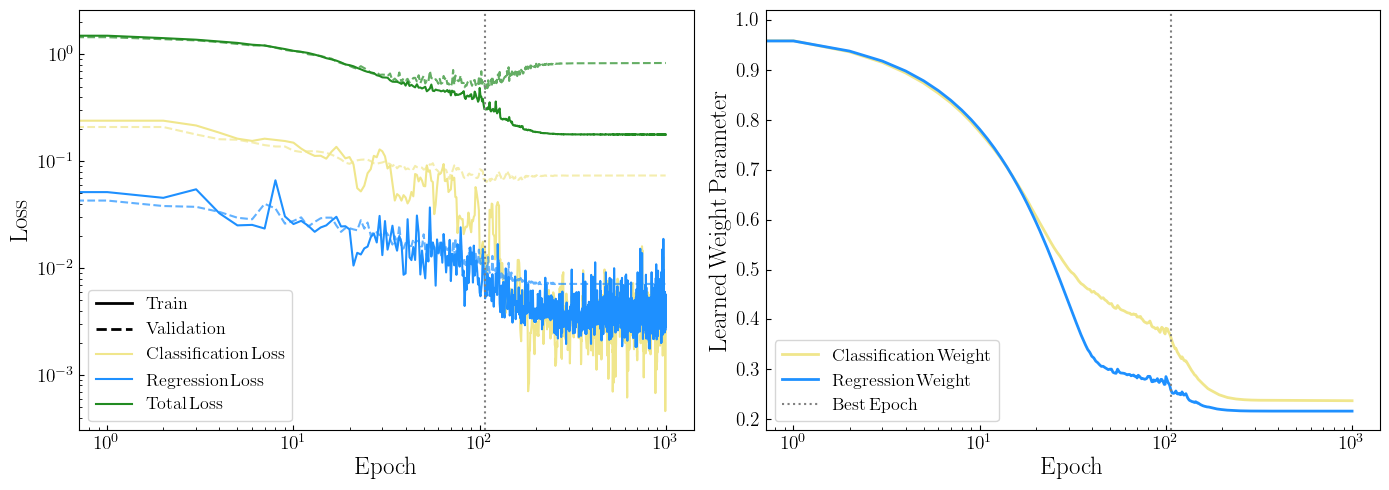

In [17]:
# Loss function plot 
train_data = pd.read_csv('MoE_0129_92hk0cay_train_loss.csv')
train_epochs = train_data['epoch']
train_class_loss = train_data['MoE_0129_92hk0cay - class_train_loss']
train_reg_loss = train_data['MoE_0129_92hk0cay - reg_train_loss']
train_total_loss = train_data['MoE_0129_92hk0cay - train_loss']

val_data = pd.read_csv('MoE_0129_92hk0cay_val_loss.csv')
val_epochs = val_data['epoch']
val_class_loss = val_data['MoE_0129_92hk0cay - class_val_loss']
val_reg_loss = val_data['MoE_0129_92hk0cay - reg_val_loss']
val_total_loss = val_data['MoE_0129_92hk0cay - val_loss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# First panel - Loss functions
ax1 = axes[0]
# Training 
ax1.plot(moving_avg(train_epochs, 5), moving_avg(train_class_loss, 5), color = 'khaki', label = r'$\rm Classification \, Loss $')
ax1.plot(train_epochs, train_reg_loss, color = 'dodgerblue', label = r'$\rm Regression \, Loss $')
ax1.plot(train_epochs, train_total_loss, color = 'forestgreen', label = r'$\rm Total \, Loss $')

# Validation
ax1.plot(moving_avg(val_epochs, 5), moving_avg(val_class_loss, 5), color = 'khaki', alpha = 0.7, linestyle='--')
ax1.plot(val_epochs, val_reg_loss, color = 'dodgerblue', alpha = 0.7, linestyle='--')
ax1.plot(val_epochs, val_total_loss, color = 'forestgreen', alpha = 0.7, linestyle='--')
print(np.argmin(val_total_loss))
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel(r"$\rm Epoch$", fontsize=18)
ax1.set_ylabel(r"$\rm Loss$", fontsize=18)
ax1.legend(fontsize=13, loc='best')
ax1.tick_params(axis='both', direction='in', labelsize=14, which='both')
ax1.axvline(x=107, color='gray', linestyle=':', linewidth=1.5)

# Add custom legend entry for line styles
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='black', linestyle='-', linewidth=2),
                Line2D([0], [0], color='black', linestyle='--', linewidth=2)]
ax1.legend(handles=custom_lines+ax1.get_legend_handles_labels()[0],
           labels=list([r'$ \rm Train $', r'$ \rm Validation $'] + ax1.get_legend_handles_labels()[1]) ,
           fontsize=13, loc='best', ncol=1)

# Second panel - weights
weights_data = pd.read_csv('MoE_0129_92hk0cay_awl_params.csv')
weights_epochs = weights_data['epoch']
weights_class = weights_data['MoE_0129_92hk0cay - awl_param_class']
weights_reg = weights_data['MoE_0129_92hk0cay - awl_param_reg']
print(weights_class[107],weights_reg[107] )
ax2 = axes[1]
ax2.plot(weights_epochs, weights_class, 
         color='khaki', linewidth=2, label=r'$\rm Classification \, Weight$')
ax2.plot(weights_epochs, weights_reg, 
         color='dodgerblue', linewidth=2, label=r'$\rm Regression \, Weight$')


ax2.set_xlabel(r"$\rm Epoch$", fontsize=18)
ax2.set_ylabel(r"$\rm Learned \, Weight \, Parameter$", fontsize=18)
ax2.tick_params(axis='both', direction='in', labelsize=14, which='both')
ax2.set_xscale('log')
ax2.axvline(x=107, color='gray', linestyle=':', linewidth=1.5, label=r'$ \rm Best \, Epoch $')
ax2.legend(fontsize=13, loc='best')
plt.tight_layout()

plt.savefig('../figures/moe_loss_function.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [16]:
#  Get best checkpoint 
model_name = './best_models/MoE_best_model.pt'
checkpoint = torch.load(model_name, map_location=torch.device('cpu'), weights_only = False)
print(checkpoint["best_epoch"])    

107
